In [1]:
"""
Voy a estudiar:

si una señal es simple o no en la base de Fourier,
cómo de rápido decrecen sus coeficientes,
cuántos coeficientes hacen falta para reconstruirla bien,
y por qué eso significa que la señal es sparse o compresible.

Básicamente queiro demostrar: la complejidad efectiva de una señal depende de la representación elegida.

Mi idea es contestar a la siguiente pregunta: ¿Por qué tendría sentido intentar reconstruir una señal con menos 
información de la que aparenta necesitar?
(porque en una base adecuada la señal tiene baja complejidad efectiva.)
"""

'\nVoy a estudiar:\n\nsi una señal es simple o no en la base de Fourier,\ncómo de rápido decrecen sus coeficientes,\ncuántos coeficientes hacen falta para reconstruirla bien,\ny por qué eso significa que la señal es sparse o compresible.\n\nBásicamente queiro demostrar: la complejidad efectiva de una señal depende de la representación elegida.\n\nMi idea es contestar a la siguiente pregunta: ¿Por qué tendría sentido intentar reconstruir una señal con menos \ninformación de la que aparenta necesitar?\n(porque en una base adecuada la señal tiene baja complejidad efectiva.)\n'

# Notebook 3 — Sparsidad y compresibilidad en la base de Fourier

## Objetivo

En este notebook se estudia experimentalmente la noción de sparsidad y compresibilidad de señales cuando se representan en la base de Fourier.

Los objetivos principales son los siguientes:

1. comparar señales con distinta estructura frecuencial;
2. analizar cómo se distribuyen sus coeficientes de Fourier;
3. estudiar el decaimiento de dichos coeficientes;
4. evaluar cómo afecta la conservación de solo los coeficientes más significativos a la calidad de la reconstrucción.

Este análisis es fundamental para el TFG, ya que permite justificar por qué, en presencia de una representación adecuada, una señal puede describirse con mucha menos información de la que su dimensión aparente sugiere. Esta idea constituye la base conceptual del marco de *Compressed Sensing*.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Configuración gráfica
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

## 1. Funciones auxiliares

Se definen funciones para:

- calcular la FFT de una señal;
- reconstruir señales a partir de coeficientes truncados;
- ordenar coeficientes por magnitud;
- y medir el error de reconstrucción.

In [3]:
def compute_fft(signal, fs):
    """
    Calcula la FFT de una señal y devuelve:
    - frecuencias positivas
    - coeficientes positivos
    - FFT completa
    """
    N = len(signal)
    fft_coeffs = np.fft.fft(signal)
    freqs = np.fft.fftfreq(N, d=1/fs)

    mask = freqs >= 0
    return freqs[mask], fft_coeffs[mask], fft_coeffs


def reconstruct_from_fft(full_fft):
    """
    Reconstruye la señal mediante la transformada inversa.
    """
    return np.fft.ifft(full_fft).real


def keep_top_k_coeffs(full_fft, k):
    """
    Conserva los k coeficientes de mayor magnitud y anula el resto.
    """
    fft_copy = np.copy(full_fft)
    magnitudes = np.abs(fft_copy)

    top_k_idx = np.argsort(magnitudes)[-k:]
    filtered_fft = np.zeros_like(fft_copy, dtype=complex)
    filtered_fft[top_k_idx] = fft_copy[top_k_idx]
    return filtered_fft


def mse(x, x_hat):
    return np.mean((x - x_hat) ** 2)


def relative_error(x, x_hat):
    return np.linalg.norm(x - x_hat) / np.linalg.norm(x)


def sorted_magnitudes(full_fft):
    """
    Devuelve las magnitudes de los coeficientes ordenadas de mayor a menor.
    """
    return np.sort(np.abs(full_fft))[::-1]

## 2. Construcción de señales de prueba

Para estudiar la noción de compresibilidad, se consideran dos señales distintas:

- una señal altamente estructurada, construida como suma de pocas senoides;
- una señal con contenido frecuencial mucho más distribuido, generada a partir de ruido aleatorio.

El contraste entre ambas permitirá ver que no todas las señales presentan el mismo grado de compacidad en la base de Fourier.

In [4]:
# Parámetros globales
fs = 500
T = 1.0
N = int(fs * T)
t = np.linspace(0, T, N, endpoint=False)

# Señal 1: estructurada, suma de pocas senoides
signal_sparse = (
    1.0 * np.sin(2 * np.pi * 5 * t) +
    0.7 * np.sin(2 * np.pi * 15 * t) +
    0.3 * np.sin(2 * np.pi * 40 * t)
)

# Señal 2: ruido aleatorio
np.random.seed(42)
signal_noise = np.random.randn(N)

## 3. Comparación en el dominio temporal

En primer lugar, se comparan ambas señales en el dominio temporal.

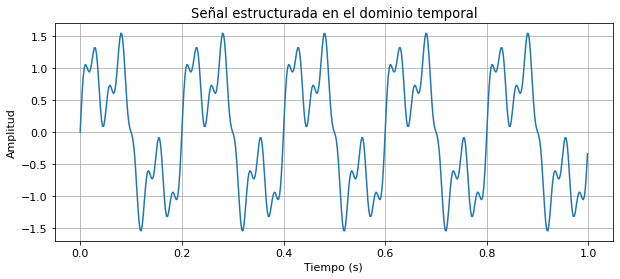

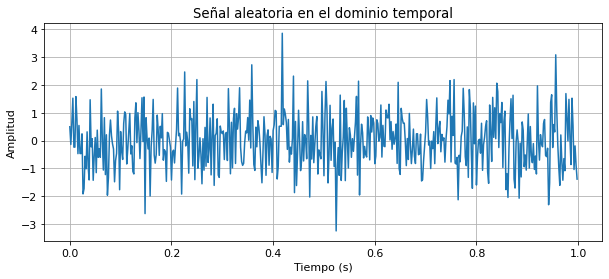

In [5]:
plt.figure()
plt.plot(t, signal_sparse)
plt.title("Señal estructurada en el dominio temporal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

plt.figure()
plt.plot(t, signal_noise)
plt.title("Señal aleatoria en el dominio temporal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

### Comentario

La primera señal presenta una estructura oscilatoria clara, mientras que la segunda muestra un comportamiento irregular y desordenado. No obstante, la verdadera diferencia relevante para este trabajo no reside tanto en el dominio temporal como en la representación frecuencial de ambas señales.

## 4. Comparación en el dominio frecuencial

Se calcula ahora la transformada de Fourier de ambas señales para estudiar cómo se distribuye la información en frecuencia.

In [6]:
freqs_sparse, fft_pos_sparse, fft_full_sparse = compute_fft(signal_sparse, fs)
freqs_noise, fft_pos_noise, fft_full_noise = compute_fft(signal_noise, fs)

mag_sparse = np.abs(fft_pos_sparse) / N
mag_noise = np.abs(fft_pos_noise) / N

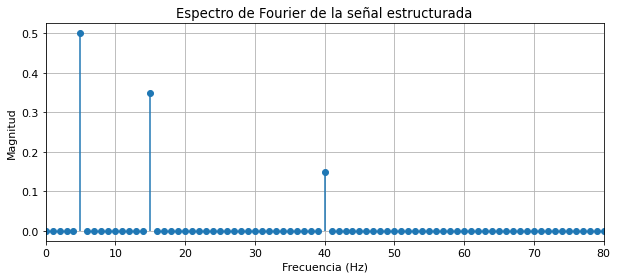

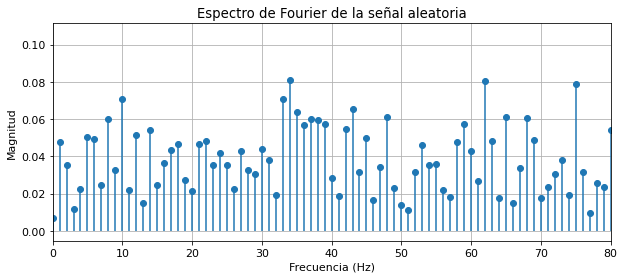

In [7]:
plt.figure()
plt.stem(freqs_sparse, mag_sparse, basefmt=" ")
plt.xlim(0, 80)
plt.title("Espectro de Fourier de la señal estructurada")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.show()

plt.figure()
plt.stem(freqs_noise, mag_noise, basefmt=" ")
plt.xlim(0, 80)
plt.title("Espectro de Fourier de la señal aleatoria")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.show()

### Interpretación

La señal estructurada concentra su energía en un número reducido de frecuencias bien localizadas. Por el contrario, la señal aleatoria distribuye su contenido a lo largo de muchas frecuencias. Esta diferencia es esencial: la primera admite una representación mucho más compacta en Fourier, mientras que la segunda no presenta la misma simplicidad estructural.

## 5. Decaimiento de coeficientes ordenados

Una manera especialmente útil de estudiar la compresibilidad de una señal consiste en ordenar los coeficientes de Fourier por magnitud decreciente y observar cómo disminuyen.

Si pocos coeficientes dominan claramente sobre el resto, la señal será altamente compresible. Si, por el contrario, los coeficientes decrecen lentamente, la representación será mucho menos eficiente.

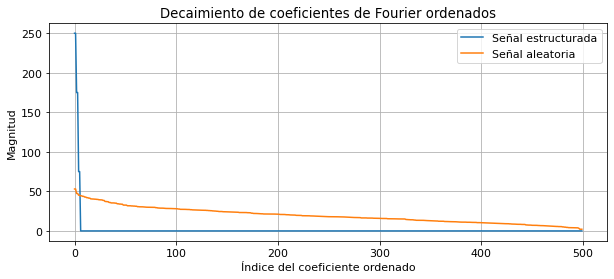

In [8]:
sorted_sparse = sorted_magnitudes(fft_full_sparse)
sorted_noise = sorted_magnitudes(fft_full_noise)

plt.figure()
plt.plot(sorted_sparse, label="Señal estructurada")
plt.plot(sorted_noise, label="Señal aleatoria")
plt.title("Decaimiento de coeficientes de Fourier ordenados")
plt.xlabel("Índice del coeficiente ordenado")
plt.ylabel("Magnitud")
plt.legend()
plt.show()

### Interpretación

Se observa que, en la señal estructurada, los coeficientes más importantes destacan claramente y el resto cae rápidamente hacia valores pequeños. En cambio, en la señal aleatoria el descenso es mucho más gradual. Esto pone de manifiesto que la primera señal es mucho más compresible en la base de Fourier que la segunda.

## 6. Reconstrucción con solo los coeficientes más significativos

A continuación se estudia cómo evoluciona la calidad de la reconstrucción cuando solo se conservan los \(k\) coeficientes más importantes en la base de Fourier.

In [9]:
k_values = [2, 4, 6, 10, 20, 50, 100]

results_sparse = []
results_noise = []

for k in k_values:
    fft_k_sparse = keep_top_k_coeffs(fft_full_sparse, k)
    rec_sparse = reconstruct_from_fft(fft_k_sparse)

    fft_k_noise = keep_top_k_coeffs(fft_full_noise, k)
    rec_noise = reconstruct_from_fft(fft_k_noise)

    results_sparse.append({
        "k": k,
        "mse": mse(signal_sparse, rec_sparse),
        "relative_error": relative_error(signal_sparse, rec_sparse),
        "reconstruction": rec_sparse
    })

    results_noise.append({
        "k": k,
        "mse": mse(signal_noise, rec_noise),
        "relative_error": relative_error(signal_noise, rec_noise),
        "reconstruction": rec_noise
    })

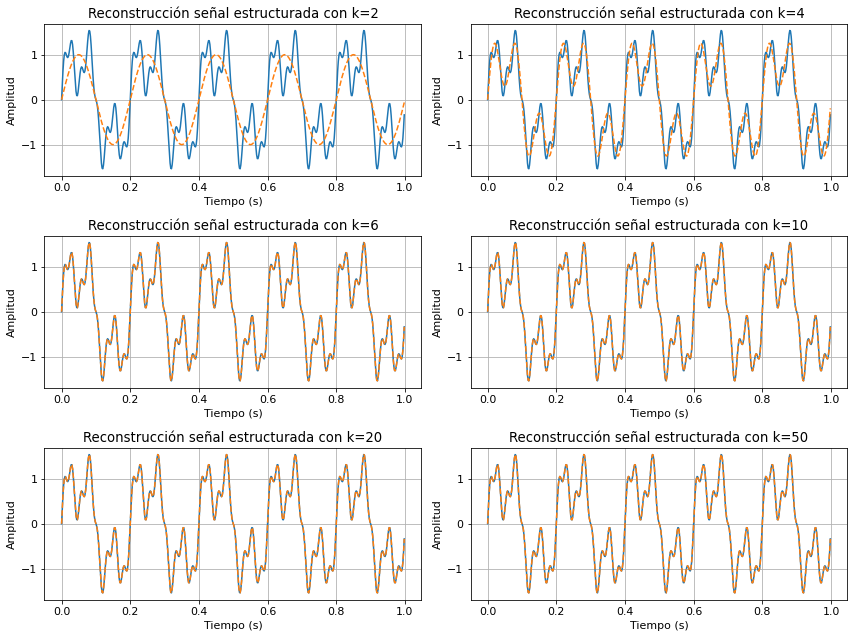

In [10]:
# Algunas reconstrucciones para la señal estructurada
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, result in zip(axes, results_sparse[:6]):
    ax.plot(t, signal_sparse, label="Original")
    ax.plot(t, result["reconstruction"], "--", label=f"k={result['k']}")
    ax.set_title(f"Reconstrucción señal estructurada con k={result['k']}")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Amplitud")

plt.tight_layout()
plt.show()

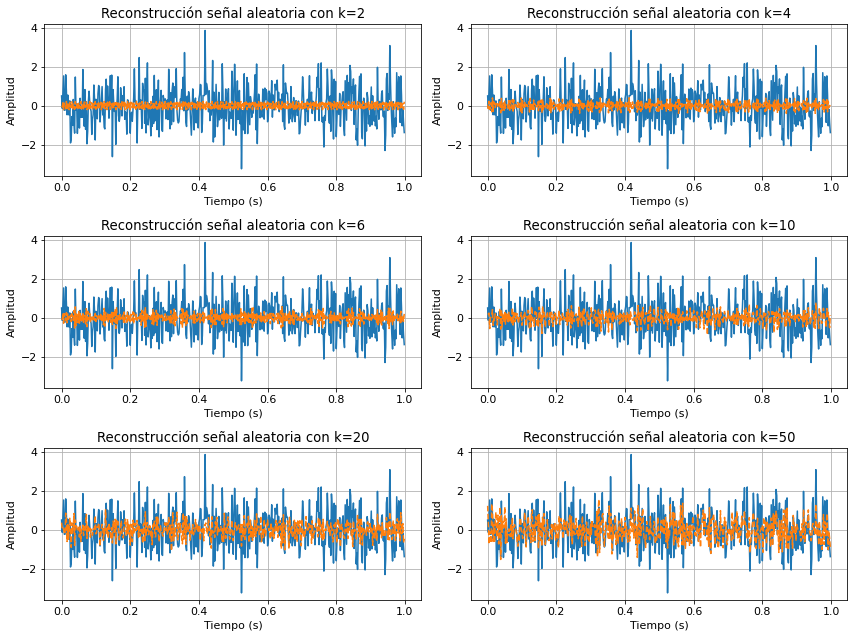

In [11]:
# Algunas reconstrucciones para la señal aleatoria
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, result in zip(axes, results_noise[:6]):
    ax.plot(t, signal_noise, label="Original")
    ax.plot(t, result["reconstruction"], "--", label=f"k={result['k']}")
    ax.set_title(f"Reconstrucción señal aleatoria con k={result['k']}")
    ax.set_xlabel("Tiempo (s)")
    ax.set_ylabel("Amplitud")

plt.tight_layout()
plt.show()

### Interpretación

En la señal estructurada, conservar unos pocos coeficientes relevantes basta para obtener una reconstrucción bastante fiel. En cambio, en la señal aleatoria la pérdida de coeficientes degrada mucho más rápidamente la calidad de la reconstrucción. Esto confirma experimentalmente que no todas las señales son igual de compresibles en la misma base.

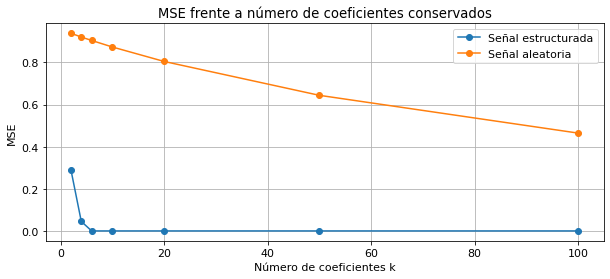

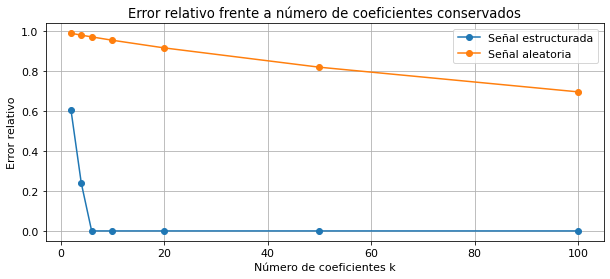

In [12]:
# Curvas de error
mse_sparse = [r["mse"] for r in results_sparse]
mse_noise = [r["mse"] for r in results_noise]

rel_sparse = [r["relative_error"] for r in results_sparse]
rel_noise = [r["relative_error"] for r in results_noise]

plt.figure()
plt.plot(k_values, mse_sparse, marker="o", label="Señal estructurada")
plt.plot(k_values, mse_noise, marker="o", label="Señal aleatoria")
plt.title("MSE frente a número de coeficientes conservados")
plt.xlabel("Número de coeficientes k")
plt.ylabel("MSE")
plt.legend()
plt.show()

plt.figure()
plt.plot(k_values, rel_sparse, marker="o", label="Señal estructurada")
plt.plot(k_values, rel_noise, marker="o", label="Señal aleatoria")
plt.title("Error relativo frente a número de coeficientes conservados")
plt.xlabel("Número de coeficientes k")
plt.ylabel("Error relativo")
plt.legend()
plt.show()

In [13]:
df_sparse = pd.DataFrame(
    [{"k": r["k"], "mse": r["mse"], "relative_error": r["relative_error"]} for r in results_sparse]
)

df_noise = pd.DataFrame(
    [{"k": r["k"], "mse": r["mse"], "relative_error": r["relative_error"]} for r in results_noise]
)

print("Resultados para la señal estructurada:")
display(df_sparse)

print("\nResultados para la señal aleatoria:")
display(df_noise)

Resultados para la señal estructurada:


,k,mse,relative_error
0,2,2.900000e-01,6.058784e-01
1,4,4.500000e-02,2.386672e-01
2,6,8.324104e-30,3.246050e-15
3,10,7.266707e-30,3.032880e-15
4,20,5.589296e-30,2.659898e-15
5,50,3.413164e-30,2.078572e-15
6,100,1.909070e-30,1.554524e-15



Resultados para la señal aleatoria:


,k,mse,relative_error
0,2,0.938479,0.988224
1,4,0.920525,0.978725
2,6,0.904229,0.970023
3,10,0.873194,0.953231
4,20,0.804553,0.914998
5,50,0.643733,0.818457
6,100,0.464330,0.695115


## 7. Conclusiones del notebook

Los experimentos realizados permiten extraer varias conclusiones importantes:

1. no todas las señales presentan el mismo grado de simplicidad en la base de Fourier;
2. una señal estructurada puede concentrar gran parte de su información en pocos coeficientes significativos;
3. una señal aleatoria distribuye su contenido frecuencial de forma mucho más extensa, por lo que su representación resulta menos compacta;
4. la calidad de la reconstrucción a partir de pocos coeficientes depende directamente del grado de compresibilidad de la señal.

Estas observaciones son esenciales para el desarrollo posterior del TFG, ya que justifican por qué las técnicas de *Compressed Sensing* pueden funcionar bien cuando la señal es sparse o compresible en una representación adecuada.